# Introducción: objetivos del proyecto

## ¿Qué vamos a predecir?

En este proyecto vamos a construir un modelo de machine learning que sea capaz de **predecir si un Pokémon es legendario o no** (`is_legendary`), a partir de sus características como tipos, estadísticas de combate, generación, color, entre otras.

Este es un problema de **clasificación binaria**, donde las clases posibles son:

- `0`: Pokémon no legendario  
- `1`: Pokémon legendario

Vamos a enfocarnos en el flujo de trabajo completo de un proyecto de ML una vez que ya se realizó la exploración y limpieza del dataset (EDA). Nuestro objetivo es seguir las buenas prácticas modernas para el desarrollo de modelos, especialmente aquellas promovidas por **scikit-learn**, la biblioteca estándar de ML en Python.

---

## ¿Por qué usamos Scikit-Learn?

[scikit-learn](https://scikit-learn.org/) es una biblioteca de Python para aprendizaje automático que ofrece:

- **Modelos clásicos de ML**: regresión, clasificación, clustering, reducción de dimensionalidad, etc.
- **Transformadores y herramientas de preprocesamiento**: escalado, imputación de valores faltantes, codificación de variables categóricas, selección de features.
- **Evaluación y validación de modelos**: métricas, validación cruzada, búsqueda de hiperparámetros.
- **Integración en pipelines reproducibles** que combinan todos los pasos del flujo de trabajo.

El objetivo de este notebook es mostrar cómo usar scikit-learn **como fue diseñado**: no solo como un conjunto de funciones o modelos sueltos, sino como un **ecosistema coherente** que favorece la reutilización, reproducibilidad y escalabilidad.

---


## Diseño de Scikit-Learn: polimorfismo y coherencia

El diseño de scikit-learn está basado en principios sólidos de ingeniería de software. Las ideas clave son:

###  Interfaces coherentes

Todas las clases principales siguen una API común con métodos predecibles:

- `fit(X, y=None)` → entrena un estimador a partir de datos.
- `transform(X)` → transforma los datos (si aplica).
- `predict(X)` → predice valores para nuevas observaciones.
- `fit_transform(X)` → combinación optimizada de fit + transform (para transformadores).
- `score(X, y)` → calcula el rendimiento del modelo.

Este diseño uniforme permite que componentes muy distintos (p. ej., un escalador de variables y un modelo predictivo) puedan combinarse y encadenarse sin esfuerzo.

---


### Composición basada en polimorfismo

Gracias a esta interfaz común, distintas piezas (modelos, transformadores, pipelines) pueden usarse **de forma intercambiable**. Por ejemplo, si entrenamos una `RandomForestClassifier` en un pipeline, podemos reemplazarla por una `LogisticRegression` o una `SVC` sin tocar el resto del código. Esto es posible porque todas comparten la misma interfaz de "predictor".

Este enfoque polimórfico es clave para:

- Reutilizar código.
- Comparar modelos fácilmente.
- Mantener el flujo modular y extensible.

---

### Composición mediante `Pipeline` y `ColumnTransformer`

scikit-learn promueve la **composición declarativa de pasos**, como en una línea de ensamblaje:

- `Pipeline`: cadena secuencial de transformaciones seguidas de un modelo.
- `ColumnTransformer`: permite aplicar diferentes transformaciones a diferentes columnas.

Esto permite definir un flujo completo de preprocesamiento + entrenamiento como un **único objeto** que puede ser:

- Entrenado con `fit`.
- Usado para predecir con `predict`.
- Validado con `cross_val_score`.
- Optimizable con `GridSearchCV`.

En este notebook vamos a seguir esta filosofía de diseño en cada paso del proyecto.

---

# Preparación inicial

En esta sección vamos a cargar el dataset con información de Pokémon, seleccionar la variable objetivo (`is_legendary`) y dividir el conjunto en entrenamiento y test.

Asumimos que el dataset ya está en formato **tidy** (una fila por Pokémon, una columna por feature), y que no requiere limpieza adicional en esta etapa.

Trabajaremos con el archivo `1000_pokemons.csv`.


In [ ]:
import pandas as pd
!gdown 15X-2yRA77spqoBjlQBRmVjIxZkOaADwP

# Cargar el dataset
df = pd.read_csv("1000pokemons.csv")
df = df.set_index("name")

# Vista rápida
df.head()


Downloading...
From: https://drive.google.com/uc?id=15X-2yRA77spqoBjlQBRmVjIxZkOaADwP
To: /content/1000pokemons.csv
100% 71.6k/71.6k [00:00<00:00, 45.8MB/s]


,id,height,weight,base_experience,generation,is_legendary,type_1,type_2,hp,attack,defense,special-attack,special-defense,speed
name,,,,,,,,,,,,,,
bulbasaur,1,7,69,64,generation-i,False,grass,poison,45,49,49,65,65,45
ivysaur,2,10,130,142,generation-i,False,grass,poison,60,62,63,80,80,60
venusaur,3,20,1000,236,generation-i,False,grass,poison,80,82,83,100,100,80
charmander,4,6,85,62,generation-i,False,fire,NaN,39,52,43,60,50,65
charmeleon,5,11,190,142,generation-i,False,fire,NaN,58,64,58,80,65,80


## Selección de features y variable objetivo

Vamos a separar las features (`X`) de la variable a predecir (`y`). En este caso, nuestra variable target es `is_legendary`, que indica si un Pokémon es legendario (`1`) o no (`0`).

Por ahora no vamos a hacer selección de variables ni ingeniería de features: simplemente eliminamos la columna `is_legendary` de los predictores.


In [ ]:
# Variable objetivo
y = df["is_legendary"]

# Features (quitamos la target)
X = df.drop(columns=["is_legendary"])


## División en conjunto de entrenamiento y test

Antes de hacer cualquier análisis o entrenamiento, debemos dividir los datos para evitar **data leakage** (filtración de información del test al entrenamiento).

Usamos `train_test_split` de `sklearn.model_selection` con una proporción 80/20 y semilla fija (`random_state=42`) para reproducibilidad.


In [ ]:
from sklearn.model_selection import train_test_split

# División 80% entrenamiento, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verificamos tamaños
print(f"Train size: {X_train.shape[0]} muestras")
print(f"Test size: {X_test.shape[0]} muestras")
print(f"Proporción de legendarios en train: {y_train.sum()/y_train.shape[0]}")
print(f"Proporción de legendarios en test: {y_test.sum()/y_test.shape[0]}")


Train size: 800 muestras
Test size: 200 muestras
Proporción de legendarios en train: 0.0525
Proporción de legendarios en test: 0.055


# Preprocesamiento con Scikit-Learn

En esta sección vamos a construir un pipeline de preprocesamiento completamente modular, utilizando las herramientas de `scikit-learn` y el diseño por etapas.

El objetivo es transformar el conjunto de entrenamiento para que todas las columnas sean **numéricas** y estén **listas para el modelado**, sin aplicar transformaciones manuales fuera del pipeline.

---



## Paso 1: Eliminación de columnas irrelevantes

Primero eliminamos columnas que no aportan valor predictivo. En este caso, eliminamos la columna `id`, que funciona como identificador único.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop)


## Paso 2: Combinación de `type_1` y `type_2`

Las columnas `type_1` y `type_2` representan los tipos principales y secundarios de cada Pokémon. Vamos a combinarlas en una sola columna llamada `type_combined` para capturar sinergias de tipos, por ejemplo `fire+flying`.

Este paso también se encapsula en un transformador personalizado para integrarlo al pipeline.


In [ ]:
class TypeCombiner(BaseEstimator, TransformerMixin):
    def __init__(self, drop_original=True):
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        X_["type_2"] = X_["type_2"].fillna("None")

        X_["type_combined"] = X_.apply(
            lambda row: row["type_1"] if row["type_2"] == "None"
            else f"{row['type_1']}+{row['type_2']}",
            axis=1
        )

        if self.drop_original:
            X_ = X_.drop(columns=["type_1", "type_2"])

        return X_


## Paso 3: Pipeline numérico

Para las columnas numéricas (como `hp`, `attack`, `height`, etc.), vamos a aplicar:

- **Imputación** de valores faltantes con la mediana (`SimpleImputer`)
- **Escalado** al rango `[0, 1]` con `MinMaxScaler`, para facilitar la interpretación y compatibilidad con modelos sensibles a la escala.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

## Paso 4: Pipeline categórico

Para las columnas categóricas (`generation`, `color`, `type_combined`) vamos a aplicar:

- **Imputación** con el valor más frecuente
- **Codificación one-hot** con `OneHotEncoder`, ignorando categorías desconocidas para robustez ante nuevos datos


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

## Paso 5: Composición con `ColumnTransformer`

Usamos `make_column_selector` para seleccionar automáticamente:

- Columnas numéricas: `int`, `float`
- Columnas categóricas: `object`, `category`

Esto hace que nuestro pipeline sea flexible y adaptable.


In [ ]:
from sklearn.compose import ColumnTransformer, make_column_selector

column_transform = ColumnTransformer([
    ("num", numeric_pipeline, make_column_selector(dtype_include=["int64", "float64"])),
    ("cat", categorical_pipeline, make_column_selector(dtype_include=["object", "category"]))
])

## Paso final: pipeline completo de preprocesamiento

Finalmente, combinamos todo en un único pipeline `preprocessor` que:

1. Elimina columnas innecesarias (`id`)
2. Combina los tipos (`type_1` + `type_2`)
3. Aplica las transformaciones numéricas y categóricas

Este pipeline transforma `X` y lo deja completamente preparado para modelado.


In [ ]:
preprocessor = Pipeline([
    ("drop_columns", DropColumns(columns_to_drop=["id","generation"])),
    ("type_combiner", TypeCombiner()),
    ("column_transform", column_transform)
])

In [ ]:
#mostrar salida de preprocesamiento
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7975 stored elements and shape (800, 195)>

In [ ]:
# Convertir la matriz dispersa a un array denso para visualización (solo las primeras filas)
import numpy as np
print("Primera fila de la matriz transformada:")
print(preprocessor.fit_transform(X_train)[0].toarray())

Primera fila de la matriz transformada:
[[0.05527638 0.04490898 0.0541958  0.42125984 0.35795455 0.17777778
  0.12269939 0.0952381  0.19487179 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.    

# Entrenamiento de modelos

Vamos a entrenar tres modelos de clasificación binaria para predecir si un Pokémon es legendario:

1. Regresión logística (`LogisticRegression`)
2. Bosque aleatorio (`RandomForestClassifier`)
3. Máquina de vectores de soporte (`SVC`)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Pipeline con Logistic Regression
pipeline_logreg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar
pipeline_logreg.fit(X_train, y_train)

# Predicciones
y_pred_logreg = pipeline_logreg.predict(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline con Random Forest
pipeline_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Entrenar
pipeline_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = pipeline_rf.predict(X_test)


In [ ]:
from sklearn.svm import SVC

# Pipeline con SVC
pipeline_svc = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(random_state=42))
])

# Entrenar
pipeline_svc.fit(X_train, y_train)

# Predicciones
y_pred_svc = pipeline_svc.predict(X_test)


## Prevención del *data leakage* gracias al uso de pipelines

Una de las ventajas clave de usar un `Pipeline` en `scikit-learn` es que nos ayuda a prevenir el **data leakage** (*fugas de datos*), una de las causas más comunes de sobreajuste y evaluación engañosa en machine learning.


### ¿Qué es el *data leakage*?

El *data leakage* ocurre cuando **información del conjunto de test (o validación)** se filtra accidentalmente durante el entrenamiento. Esto puede hacer que el modelo obtenga métricas artificialmente altas, pero que falle al generalizar a datos nuevos.

Ejemplos comunes de data leakage:

- Imputar valores faltantes usando la media calculada en todo el dataset (incluyendo el test).
- Escalar variables (como normalización o estandarización) usando estadísticas del conjunto completo.
- Codificar variables categóricas con valores de frecuencia global que incluyen el test.


### ¿Cómo lo evitamos usando un `Pipeline`?

Cuando encapsulamos todo el preprocesamiento en un `Pipeline` y hacemos:

```python
pipeline.fit(X_train, y_train)
````

o usamos validación cruzada como:

```python
cross_val_score(pipeline, X, y, cv=5)
```

scikit-learn se encarga automáticamente de:

1. Ajustar (`fit`) cada transformador **solo con los datos de entrenamiento**.
2. Transformar (`transform`) los datos de test o validación sin que afecten el ajuste.
3. Evitar cualquier fuga de información del futuro (test) hacia el pasado (entrenamiento).





# Evaluación de modelos

En esta sección vamos a evaluar el rendimiento de los tres modelos entrenados:

1. Regresión logística
2. Random Forest
3. SVM (máquina de vectores de soporte)

Vamos a utilizar las siguientes métricas:

- **Accuracy**: proporción total de aciertos
- **Precision**: cuántos de los predichos como positivos realmente lo son
- **Recall**: cuántos de los positivos reales fueron identificados
- **F1-score**: balance entre precision y recall
- **Confusion matrix**: para ver aciertos y errores por clase

Estas métricas son especialmente importantes en contextos con clases desbalanceadas como este.


In [ ]:
from sklearn.metrics import classification_report,


# Función para evaluar modelos
def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n🔎 {nombre}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

# Evaluación de los tres modelos
evaluar_modelo("Logistic Regression", y_test, y_pred_logreg)
evaluar_modelo("Random Forest", y_test, y_pred_rf)
evaluar_modelo("Support Vector Classifier", y_test, y_pred_svc)



🔎 Logistic Regression

Classification report:
              precision    recall  f1-score   support

       False      0.950     1.000     0.974       189
        True      1.000     0.091     0.167        11

    accuracy                          0.950       200
   macro avg      0.975     0.545     0.570       200
weighted avg      0.953     0.950     0.930       200

Confusion matrix:
[[189   0]
 [ 10   1]]

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

       False      0.964     1.000     0.982       189
        True      1.000     0.364     0.533        11

    accuracy                          0.965       200
   macro avg      0.982     0.682     0.758       200
weighted avg      0.966     0.965     0.957       200

Confusion matrix:
[[189   0]
 [  7   4]]

🔎 Support Vector Classifier

Classification report:
              precision    recall  f1-score   support

       False      0.945     1.000     0.972       189
        True  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Análisis de resultados

- Es posible que todos los modelos muestren un `accuracy` alto, simplemente por predecir siempre la clase mayoritaria.
- El `recall` y el `f1-score` de la clase minoritaria (`1`, es decir, Pokémon legendarios) probablemente sean bajos.
- Esto indica que los modelos base **no están aprendiendo a identificar correctamente a los legendarios**, lo cual es esperable dado el desbalance de clases.

---

En la siguiente sección vamos a explorar formas de mejorar estos resultados mediante técnicas de balanceo como:

- Penalización de clases (`class_weight='balanced'`)
- Oversampling con SMOTE


In [ ]:
# Índices de los ejemplos que fueron clasificados como legendarios por el modelo de Random Forest
X_test[y_pred_rf == 1]


,id,height,weight,base_experience,generation,type_1,type_2,hp,attack,defense,special-attack,special-defense,speed
name,,,,,,,,,,,,,
mewtwo,150,20,1220,306,generation-i,psychic,NaN,106,110,90,154,90,130
lugia,249,52,2160,306,generation-ii,psychic,flying,106,90,130,90,154,110
zacian,888,28,1100,335,generation-viii,fairy,NaN,92,120,115,80,115,138
kyogre,382,45,3520,302,generation-iii,water,NaN,100,100,90,150,140,90


# Abordaje del desbalance de clases

En secciones anteriores observamos que nuestros modelos tienen dificultades para predecir correctamente los Pokémon legendarios (`is_legendary = 1`), que representan una clase minoritaria.

Esto es esperable debido al **desbalance de clases** en el dataset. Para mejorar el rendimiento, vamos a explorar dos estrategias comunes:

1. Ajustar el peso de las clases en la función de pérdida (`class_weight='balanced'`)
2. Aplicar técnicas de *oversampling*, como **SMOTE**, para balancear artificialmente el conjunto de entrenamiento

Comencemos por el ajuste de pesos.


## Ajuste de pesos con `class_weight='balanced'`

Varios modelos en `scikit-learn` permiten ajustar el impacto de cada clase en la función de pérdida mediante el argumento `class_weight='balanced'`.

Esto penaliza más los errores en la clase minoritaria, forzando al modelo a prestarle atención.

A continuación vamos a volver a entrenar nuestros tres modelos clásicos pero con esta opción activada.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Pipeline con Logistic Regression balanceado
pipeline_logreg_bal = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Pipeline con Random Forest balanceado
pipeline_rf_bal = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Pipeline con SVC balanceado
pipeline_svc_bal = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(class_weight='balanced', random_state=42))
])


In [ ]:
# Entrenamiento
pipeline_logreg_bal.fit(X_train, y_train)
pipeline_rf_bal.fit(X_train, y_train)
pipeline_svc_bal.fit(X_train, y_train)

# Predicciones
y_pred_logreg_bal = pipeline_logreg_bal.predict(X_test)
y_pred_rf_bal = pipeline_rf_bal.predict(X_test)
y_pred_svc_bal = pipeline_svc_bal.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Función para evaluar modelos
def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n🔎 {nombre}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

# Evaluación de los tres modelos
evaluar_modelo("Logistic Regression", y_test, y_pred_logreg_bal)
evaluar_modelo("Random Forest", y_test, y_pred_rf_bal)
evaluar_modelo("Support Vector Classifier", y_test, y_pred_svc_bal)



🔎 Logistic Regression

Classification report:
              precision    recall  f1-score   support

       False      0.988     0.889     0.936       189
        True      0.300     0.818     0.439        11

    accuracy                          0.885       200
   macro avg      0.644     0.854     0.687       200
weighted avg      0.950     0.885     0.909       200

Confusion matrix:
[[168  21]
 [  2   9]]

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

       False      0.964     1.000     0.982       189
        True      1.000     0.364     0.533        11

    accuracy                          0.965       200
   macro avg      0.982     0.682     0.758       200
weighted avg      0.966     0.965     0.957       200

Confusion matrix:
[[189   0]
 [  7   4]]

🔎 Support Vector Classifier

Classification report:
              precision    recall  f1-score   support

       False      0.978     0.921     0.948       189
        True  

## Rebalanceo del entrenamiento con SMOTE

Otra forma de combatir el desbalance es generar artificialmente más observaciones de la clase minoritaria utilizando técnicas de *oversampling*.

En este caso aplicamos **SMOTE (Synthetic Minority Oversampling Technique)**, que crea nuevas observaciones sintéticas combinando vecinos de la clase minoritaria.

Para poder usar SMOTE sin generar *data leakage*, integramos todo el flujo dentro de un `Pipeline` de `imblearn`, que permite insertar un paso de oversampling entre el preprocesamiento y el modelo.

> ⚠️ Importante: no podemos incluir un `Pipeline` completo como paso intermedio, ya que `Pipeline` no permite pasos que sean a su vez otros `Pipeline`s. En su lugar, descomponemos el preprocesamiento en pasos individuales dentro del pipeline general.



In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Logistic Regression + SMOTE
pipeline_logreg_smote = ImbPipeline([
    ("drop_columns", DropColumns(columns_to_drop=["id"])),
    ("type_combiner", TypeCombiner()),
    ("column_transform", column_transform),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest + SMOTE
pipeline_rf_smote = ImbPipeline([
    ("drop_columns", DropColumns(columns_to_drop=["id"])),
    ("type_combiner", TypeCombiner()),
    ("column_transform", column_transform),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

# SVC + SMOTE
pipeline_svc_smote = ImbPipeline([
    ("drop_columns", DropColumns(columns_to_drop=["id"])),
    ("type_combiner", TypeCombiner()),
    ("column_transform", column_transform),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(random_state=42))
])



In [ ]:
pipeline_logreg_smote.fit(X_train, y_train)
pipeline_rf_smote.fit(X_train, y_train)
pipeline_svc_smote.fit(X_train, y_train)

y_pred_logreg_smote = pipeline_logreg_smote.predict(X_test)
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_pred_svc_smote = pipeline_svc_smote.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Función para evaluar modelos
def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n🔎 {nombre}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

# Evaluación de los tres modelos
evaluar_modelo("Logistic Regression", y_test, y_pred_logreg_smote)
evaluar_modelo("Random Forest", y_test, y_pred_rf_smote)
evaluar_modelo("Support Vector Classifier", y_test, y_pred_svc_smote)


🔎 Logistic Regression

Classification report:
              precision    recall  f1-score   support

       False      0.983     0.942     0.962       189
        True      0.421     0.727     0.533        11

    accuracy                          0.930       200
   macro avg      0.702     0.835     0.748       200
weighted avg      0.952     0.930     0.939       200

Confusion matrix:
[[178  11]
 [  3   8]]

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

       False      0.989     0.974     0.981       189
        True      0.643     0.818     0.720        11

    accuracy                          0.965       200
   macro avg      0.816     0.896     0.851       200
weighted avg      0.970     0.965     0.967       200

Confusion matrix:
[[184   5]
 [  2   9]]

🔎 Support Vector Classifier

Classification report:
              precision    recall  f1-score   support

       False      0.974     0.974     0.974       189
        True  

# Ajuste de hiperparámetros

Ahora que tenemos pipelines funcionales para preprocesar y entrenar nuestros modelos, vamos a aplicar técnicas de búsqueda para encontrar los **mejores hiperparámetros** para cada uno.

Usaremos `GridSearchCV`, que evalúa todas las combinaciones posibles de los parámetros especificados mediante validación cruzada (por defecto, `cv=5`).

En esta sección vamos a hacer *tuneo de hiperparámetros* para:

- Regresión logística (`LogisticRegression`)
- Bosque aleatorio (`RandomForestClassifier`)
- Máquina de vectores de soporte (`SVC`)

> 🔎 Nota: usaremos los pipelines **sin SMOTE** para mantener el proceso de validación cruzada puro. Aplicar oversampling en CV requiere enfoques más avanzados (como `Pipeline` con `imblearn` + `StratifiedKFold`).


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Pipeline
pipeline_logreg_grid = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Grilla de búsqueda
param_grid_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

# Búsqueda
grid_logreg = GridSearchCV(
    pipeline_logreg_grid,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_logreg.fit(X_train, y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('drop_columns',
                                                         DropColumns(columns_to_drop=['id',
                                                                                      'generation'])),
                                                        ('type_combiner',
                                                         TypeCombiner()),
                                                        ('column_transform',
                                                         ColumnTransformer(transformers=[('num',
                                                                                          Pipeline(steps=[('imputer',
                                                                                                           SimpleImputer(strategy='median')),
                                                                                                          ('scaler',
                                                                                                           MinMaxScaler())]),
                                                                                          <sklearn.compose._column_t...
                                                                                                          ('onehot',
                                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                                          <sklearn.compose._column_transformer.make_column_selector object at 0x78f8f11f4500>)]))])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [ ]:
print("Best parameters (Logistic Regression):")
print(grid_logreg.best_params_)

# Evaluación en test
evaluar_modelo("Logistic Regression", y_test, y_pred_logreg_bal)
y_pred_logreg_grid = grid_logreg.predict(X_test)
evaluar_modelo("Logistic Regression", y_test, y_pred_logreg_grid)


Best parameters (Logistic Regression):
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

🔎 Logistic Regression

Classification report:
              precision    recall  f1-score   support

       False      0.988     0.889     0.936       189
        True      0.300     0.818     0.439        11

    accuracy                          0.885       200
   macro avg      0.644     0.854     0.687       200
weighted avg      0.950     0.885     0.909       200

Confusion matrix:
[[168  21]
 [  2   9]]

🔎 Logistic Regression

Classification report:
              precision    recall  f1-score   support

       False      0.994     0.899     0.944       189
        True      0.345     0.909     0.500        11

    accuracy                          0.900       200
   macro avg      0.669     0.904     0.722       200
weighted avg      0.958     0.900     0.920       200

Confusion matrix:
[[170  19]
 [  1  10]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline
pipeline_rf_grid = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

# Grilla de parámetros
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

# Búsqueda
grid_rf = GridSearchCV(
    pipeline_rf_grid,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('drop_columns',
                                                         DropColumns(columns_to_drop=['id',
                                                                                      'generation'])),
                                                        ('type_combiner',
                                                         TypeCombiner()),
                                                        ('column_transform',
                                                         ColumnTransformer(transformers=[('num',
                                                                                          Pipeline(steps=[('imputer',
                                                                                                           SimpleImputer(strategy='median')),
                                                                                                          ('scaler',
                                                                                                           MinMaxScaler())]),
                                                                                          <sklearn.compose._column_t...
                                                                                                          ('onehot',
                                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                                          <sklearn.compose._column_transformer.make_column_selector object at 0x78f8f11f4500>)]))])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='f1')

In [ ]:
print("Best parameters (Random Forest):")
print(grid_rf.best_params_)

evaluar_modelo("Random Forest", y_test, y_pred_rf_bal)
y_pred_rf_grid = grid_rf.predict(X_test)
print("\nClassification Report (Random Forest - tuned):")
evaluar_modelo("Random Forest", y_test, y_pred_rf_grid)

Best parameters (Random Forest):
{'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 200}

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

       False      0.964     1.000     0.982       189
        True      1.000     0.364     0.533        11

    accuracy                          0.965       200
   macro avg      0.982     0.682     0.758       200
weighted avg      0.966     0.965     0.957       200

Confusion matrix:
[[189   0]
 [  7   4]]

Classification Report (Random Forest - tuned):

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

       False      0.989     0.958     0.973       189
        True      0.529     0.818     0.643        11

    accuracy                          0.950       200
   macro avg      0.759     0.888     0.808       200
weighted avg      0.964     0.950     0.955       200

Confusion matrix:
[[181   8]
 [  2   9]]


In [ ]:
from sklearn.svm import SVC

# Pipeline
pipeline_svc_grid = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(
        class_weight='balanced',
        random_state=42
    ))
])

# Grilla de parámetros
param_grid_svc = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

# Búsqueda
grid_svc = GridSearchCV(
    pipeline_svc_grid,
    param_grid=param_grid_svc,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_svc.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('drop_columns',
                                                         DropColumns(columns_to_drop=['id',
                                                                                      'generation'])),
                                                        ('type_combiner',
                                                         TypeCombiner()),
                                                        ('column_transform',
                                                         ColumnTransformer(transformers=[('num',
                                                                                          Pipeline(steps=[('imputer',
                                                                                                           SimpleImputer(strategy='median')),
                                                                                                          ('scaler',
                                                                                                           MinMaxScaler())]),
                                                                                          <sklearn.compose._column_t...
                                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                                          ('onehot',
                                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                                          <sklearn.compose._column_transformer.make_column_selector object at 0x7b58c7abf4d0>)]))])),
                                       ('model',
                                        SVC(class_weight='balanced',
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf']},
             scoring='f1')

In [ ]:
print("Best parameters (SVC):")
print(grid_svc.best_params_)

y_pred_svc_grid = grid_svc.predict(X_test)
print("\nClassification Report (SVC - tuned):")
evaluar_modelo("SVC", y_test, y_pred_svc_grid)


Best parameters (SVC):
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Classification Report (SVC - tuned):

🔎 SVC

Classification report:
              precision    recall  f1-score   support

       False      0.988     0.899     0.942       189
        True      0.321     0.818     0.462        11

    accuracy                          0.895       200
   macro avg      0.655     0.859     0.702       200
weighted avg      0.952     0.895     0.915       200

Confusion matrix:
[[170  19]
 [  2   9]]


# Interpretabilidad de modelos

Una parte clave en cualquier proyecto de machine learning es entender **por qué** el modelo toma las decisiones que toma.

En esta sección vamos a explorar cómo interpretar cada uno de los tres modelos que entrenamos:

- `LogisticRegression`: coeficientes de regresión → importancia y dirección de cada feature
- `RandomForestClassifier`: importancia de features basada en disminución de impureza
- `SVC`: limitado en interpretabilidad directa, pero podemos usar métodos como SHAP



## Coeficientes de `LogisticRegression`

El modelo lineal permite interpretar los coeficientes directamente:

- Signo positivo → mayor probabilidad de ser legendario
- Signo negativo → menor probabilidad
- Magnitud → fuerza del impacto

Primero ajustamos el modelo sobre todo el conjunto de entrenamiento.


In [ ]:
# Ajustar modelo final con preprocesamiento + pesos balanceados
pipeline_logreg_final = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
pipeline_logreg_final.fit(X_train, y_train)

# Extraer nombres de features (tras one-hot y escalado)
feature_names = pipeline_logreg_final.named_steps["preprocessing"].named_steps["column_transform"].get_feature_names_out()

# Extraer coeficientes
coefs = pipeline_logreg_final.named_steps["model"].coef_[0]

# Crear DataFrame ordenado
import pandas as pd
df_coef = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values(by="coef", key=abs, ascending=False)

df_coef.head(10)


,feature,coef
147,cat__type_combined_psychic,3.200663
8,num__speed,2.774118
7,num__special-defense,2.488202
1,num__weight,2.449635
2,num__base_experience,2.390955
6,num__special-attack,2.376532
153,cat__type_combined_psychic+grass,2.330863
61,cat__type_combined_fighting,2.214057
5,num__defense,2.114859
45,cat__type_combined_dragon+psychic,1.780580


## Importancia de variables en `RandomForestClassifier`

Random Forest permite acceder a la importancia de cada variable a partir de la cantidad de veces que fue usada en splits importantes.

Esto nos da una noción de qué variables fueron más influyentes, aunque no podemos saber en qué dirección influye cada una.


In [ ]:
pipeline_rf_final = ImbPipeline([
    ("drop_columns", DropColumns(columns_to_drop=["id"])),
    ("type_combiner", TypeCombiner()),
    ("column_transform", column_transform),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])
pipeline_rf_final.fit(X_train, y_train)

# Nombres de features e importancias
feature_names = pipeline_rf_final.named_steps["column_transform"].get_feature_names_out()
importancias = pipeline_rf_final.named_steps["model"].feature_importances_

df_import = pd.DataFrame({
    "feature": feature_names,
    "importance": importancias
}).sort_values(by="importance", ascending=False)

df_import.head(10)


,feature,importance
2,num__base_experience,0.186241
7,num__special-defense,0.100970
5,num__defense,0.089989
8,num__speed,0.082278
6,num__special-attack,0.078119
0,num__height,0.067067
3,num__hp,0.063213
4,num__attack,0.049081
1,num__weight,0.048198
156,cat__type_combined_psychic,0.028381


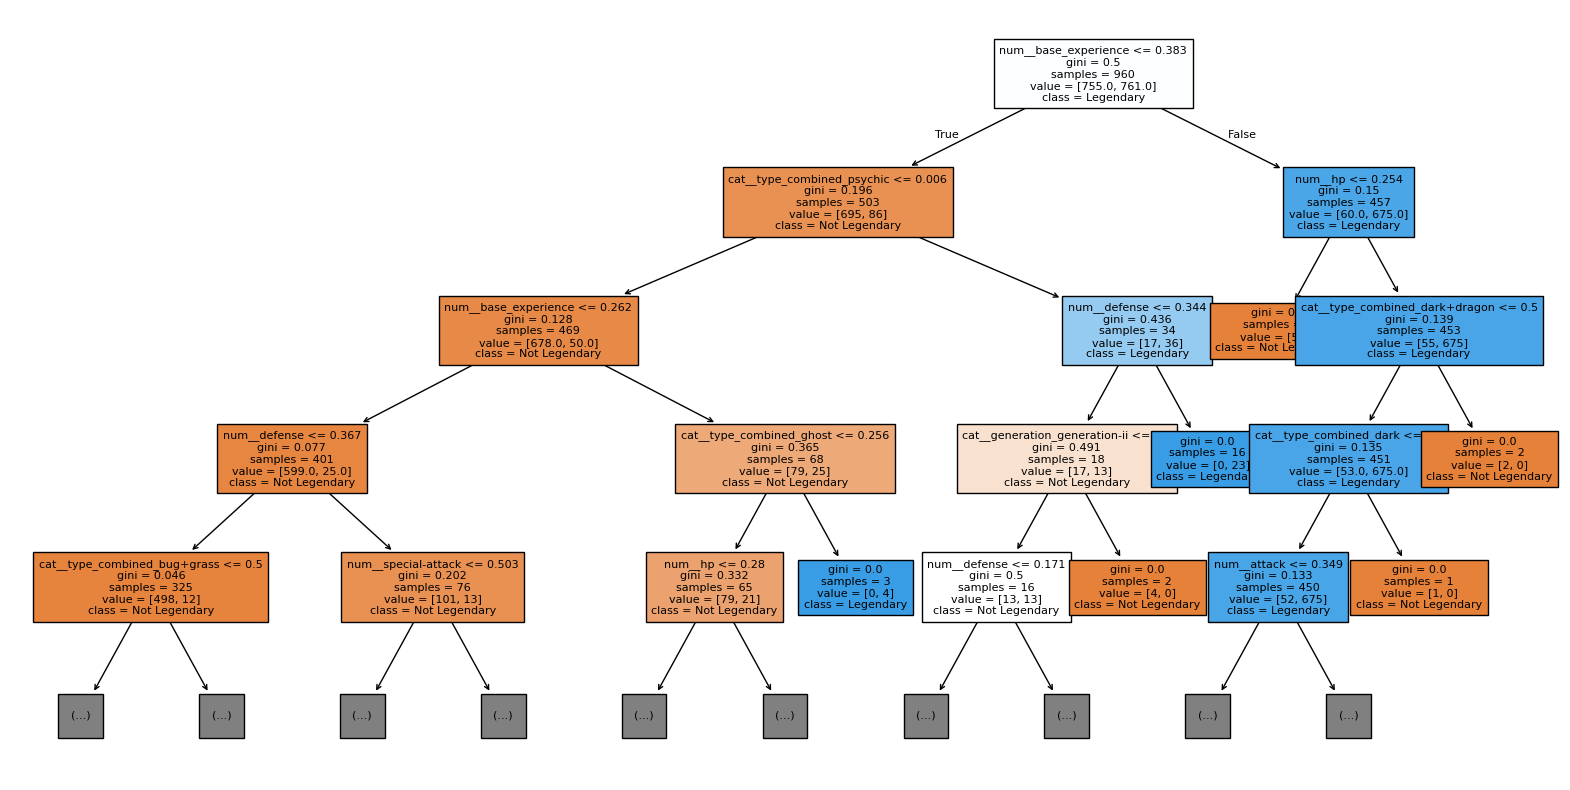

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Accedemos al primer árbol del bosque
tree = pipeline_rf_final.named_steps["model"].estimators_[0]

# Nombres de features ya transformados
feature_names = pipeline_rf_final.named_steps["column_transform"] \
                                 .get_feature_names_out()

# Graficamos
plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=feature_names,
          class_names=["Not Legendary", "Legendary"],
          filled=True,
          max_depth=4,  # ajustá esto si querés más o menos profundidad
          fontsize=8)
plt.show()
